In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv("Online_Retail_II.CSV")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
print(df.shape)
df.isnull().sum()

(541909, 8)


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [20]:
df_clean = df.dropna(subset=['CustomerID'])

In [21]:
print(df.shape)
print(df_clean.shape)

(541909, 8)
(406829, 8)


In [27]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(df_clean.shape)

(397884, 8)


In [29]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [30]:
print(df_clean.shape)
df_clean.head()

(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [31]:
import datetime

In [35]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [39]:
snapshot_date = df_clean['InvoiceDate'].max() + datetime.timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [42]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'))
rfm.head()

,Recency,frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [49]:
print("Avg Recency:", rfm['Recency'].mean())
print("Avg Frequency:", rfm['Frequency'].mean())
print("AVG Monetary:", rfm['Monetary'].mean())

rfm.describe()

Avg Recency: 92.53642231443061
Avg Frequency: 4.272014753342554
AVG Monetary: 2054.2664601198708


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index,columns=['Recency','Frequncy', 'Monetary'])
rfm_scaled.head()

,Recency,Frequncy,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


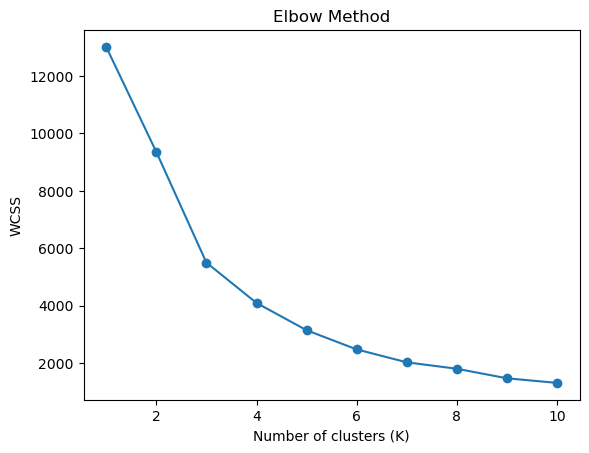

In [61]:
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt 

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figsize=(8,9)
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [63]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm['Cluster'].value_counts())

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


In [65]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


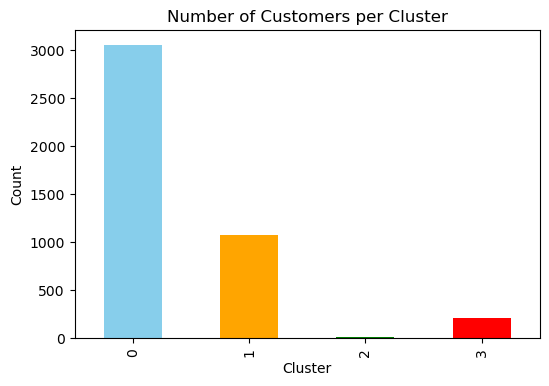

In [70]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(6,4))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color=['skyblue','orange','green','red'])
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [75]:
print(rfm.columns)
print(rfm.head())

Index(['Recency', 'Frequency', 'Monetary', 'cluster', 'Cluster'], dtype='object')
            Recency  Frequency  Monetary  cluster  Cluster
CustomerID                                                
12346.0         326          1  77183.60        3        3
12347.0           2          7   4310.00        0        0
12348.0          75          4   1797.24        0        0
12349.0          19          1   1757.55        0        0
12350.0         310          1    334.40        1        1


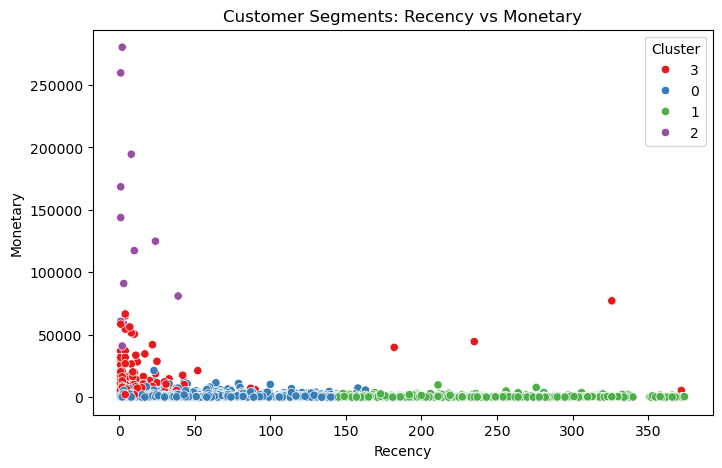

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns 

rfm['Cluster'] = rfm['Cluster'].astype(str)

plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Customer Segments: Recency vs Monetary')
plt.show()

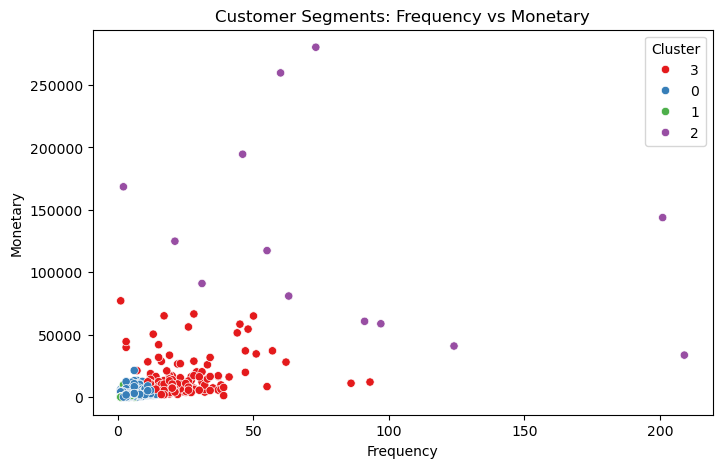

In [80]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Customer Segments: Frequency vs Monetary')
plt.show()

In [ ]:
K-Means clustering with k=4 segmented 4,418 customers into four distinct groups Cluster 2 (n=13) represents VIP Champions with the hihgest monetary 
value (avg 1312k). Cluster 3 (n=284) represents loyal Customers. Cluster 0 (n=1067) is At-Risk with higest Recency (248 days).
Visualizations of frequency vs Monetary and Recency Monetary confirm clear  separation between high-value and low-value segments enabeing targetd 
retention strategies.